In [ ]:
import numpy as np
from PIL import Image
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import numpy as np

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from collections import Counter
from torch.utils.data import random_split


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"omermumtaz05","key":"1846185668b797b4b6f897f872ae6b70"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! pip install -q kaggle
# dowload and unzip the dataset
!kaggle datasets download -d alessiocorrado99/animals10
!unzip animals10.zip


Streaming output truncated to the last 5000 lines.
  inflating: raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwHaFW.jpeg  
  inflating: raw-img/ragno/OIP-MgCgailkT5XkO1XczzQCngHaLK.jpeg  
  inflating: raw-img/ragno/OIP-MgrKq05YHGXsgj1AmYIyJQHaE8.jpeg  
  inflating: raw-img/ragno/OIP-MhRGx7d8nbnHBuqrsO00EQHaFo.jpeg  
  inflating: raw-img/ragno/OIP-MiVgMXcKGQdog2KGe7i0YQHaHh.jpeg  
  inflating: raw-img/ragno/OIP-Mis0lJf3

In [ ]:
training_dataset_path = './raw-img'

print(os.getcwd())                    # your current working directory

print(os.listdir('./raw-img')) # check the 6 class folders inside 'Images'

/content
['elefante', 'mucca', 'ragno', 'pecora', 'scoiattolo', 'gatto', 'farfalla', 'cavallo', 'cane', 'gallina']


In [ ]:
base_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Grayscale(num_output_channels=3),   # Convert 1-channel grayscale → 3 identical channels
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

])



aug_transform = transforms.Compose([ #augmented
    transforms.Resize(256), # Removed: Applied in base_transform
    transforms.CenterCrop(224), # Removed: Applied in base_transform
    transforms.Grayscale(num_output_channels=3),   # Removed: Applied in base_transform
    transforms.ToTensor(), # Removed: Applied in base_transform
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # Removed: Applied in base_transform
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(224, padding = 4), # Changed crop size to match CenterCrop output
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

In [ ]:
from torch.utils.data import Dataset

#class AugmentedSubset(Dataset):
 #   def __init__(self, dataset, indices, transform, num_copies=1):
  #      self.dataset = dataset
   ##    self.transform = transform
   #     self.num_copies = num_copies

    #def __len__(self):
     #   return len(self.indices) * self.num_copies

    #def __getitem__(self, idx):
     #   orig_idx = self.indices[idx % len(self.indices)]
      #  image, label = self.dataset[orig_idx]
        # image is already a tensor from base_transform
      #  image = self.transform(image)
       # return image, label

In [ ]:
full_dataset = datasets.ImageFolder(root=training_dataset_path)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_indices, test_indices = random_split(range(len(full_dataset)), [train_size, test_size])


train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=training_dataset_path, transform=aug_transform),
    train_indices
)

test_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=training_dataset_path, transform=base_transform),
    test_indices
)

In [ ]:
train_dataset.dataset.transform = aug_transform
test_dataset.dataset.transform = base_transform

In [ ]:
test_dataset

In [ ]:
from collections import Counter

targets = [label for _, label in train_dataset]
class_counts = Counter(targets)





In [ ]:
class_counts

Counter({1: 2119,
         0: 3933,
         8: 3804,
         2: 1152,
         7: 1475,
         4: 2519,
         9: 1448,
         5: 1314,
         6: 1486,
         3: 1693})

In [ ]:


class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in targets]


In [ ]:
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(targets),
    replacement=True
)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 32, sampler = sampler)

In [ ]:
train_dataset.dataset.transform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomCrop(size=(224, 224), padding=4)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
)

In [ ]:
test_dataset.dataset.transform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)

In [ ]:

test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [ ]:
import torch

# Simulate one full pass through the sampler
sampled_indices = list(sampler)

# Get labels for those sampled indices
sampled_labels = [train_dataset[i][1] for i in sampled_indices]

# Count how many times each class was sampled
sampled_class_counts = Counter(sampled_labels)

# Print or inspect counts
for cls in sorted(sampled_class_counts):
    print(f"Class {cls}: {sampled_class_counts[cls]} samples")


Class 0: 2116 samples
Class 1: 2183 samples
Class 2: 2151 samples
Class 3: 2089 samples
Class 4: 2059 samples
Class 5: 2082 samples
Class 6: 2100 samples
Class 7: 2039 samples
Class 8: 2039 samples
Class 9: 2085 samples


In [ ]:
sampled_class_counts

Counter({5: 2082,
         3: 2089,
         1: 2183,
         2: 2151,
         6: 2100,
         4: 2059,
         0: 2116,
         8: 2039,
         9: 2085,
         7: 2039})

In [ ]:
train_loader

In [ ]:
os.listdir(training_dataset_path)

['elefante',
 'mucca',
 'ragno',
 'pecora',
 'scoiattolo',
 'gatto',
 'farfalla',
 'cavallo',
 'cane',
 'gallina']

In [ ]:
test_loader

In [ ]:

resnet18 = torchvision.models.resnet18()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = resnet18.to(device)
#X_batch, y_batch = X_batch.to(device), y_batch.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.parameters(), lr = 0.001)

In [ ]:


gpu_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if gpu_available else "No GPU detected"

print(f"GPU available: {gpu_available}")
print(f"GPU name: {gpu_name}")

GPU available: True
GPU name: Tesla T4


In [ ]:
from sklearn.metrics import f1_score

num_classes = 10
epochs = 15

train_losses = []
test_losses = []

train_total_corr = []
test_total_corr = []

f1_score_per_epoch = []

train_correct_per_class = [0] * num_classes
test_correct_per_class = [0] * num_classes

train_count_per_class = [0] * num_classes
test_count_per_class = [0] * num_classes

for i in range(epochs):

    trn_corr = 0
    tst_corr = 0

    train_loss_per_epoch = 0
    test_loss_per_epoch = 0

    train_b_count = 0
    test_b_count = 0

    avg_train_loss_per_epoch = 0
    avg_test_loss_per_epoch = 0


    for b,(X_train, y_train) in enumerate(train_loader):
        b += 1
        train_b_count += 1

        X_train, y_train = X_train.to(device), y_train.to(device)
        y_pred = resnet18(X_train)
        loss = criterion(y_pred, y_train)
        train_loss_per_epoch += loss.item()


        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr

        for class_label, pred in zip(y_train, predicted):
            class_label = class_label.item()
            pred = pred.item()

            train_count_per_class[class_label] += 1
            if(class_label == pred):
                train_correct_per_class[class_label] += 1


        #update params
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%100 == 0:
            print(f'Epoch: {i}, Batch: {b}, Loss: {loss.item()}')

    avg_train_loss_per_epoch = train_loss_per_epoch/train_b_count

    train_losses.append(avg_train_loss_per_epoch)
    train_total_corr.append(trn_corr.item())


    with torch.no_grad():
        all_test_labels = []
        all_test_preds = []


        for b,(X_test, y_test) in enumerate(test_loader):
            test_b_count += 1
            X_test, y_test = X_test.to(device), y_test.to(device)
            y_val = resnet18(X_test)
            predicted = torch.max(y_val.data, 1)[1]
            tst_corr += (predicted == y_test).sum()

            loss = criterion(y_val, y_test)
            test_loss_per_epoch += loss.item()

            # Append all labels and predictions to lists
            all_test_labels.extend(y_test.cpu().numpy())
            all_test_preds.extend(predicted.cpu().numpy())

            for test_label, pred in zip(y_test, predicted):
                test_label = test_label.item()
                pred = pred.item()

                if(test_label == pred):
                    test_correct_per_class[test_label] += 1

                test_count_per_class[test_label] += 1


    avg_test_loss_per_epoch = test_loss_per_epoch/test_b_count
    test_losses.append(avg_test_loss_per_epoch)
    test_total_corr.append(tst_corr.item())

    # Example: print F1 score for test set
    f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
    f1_score_per_epoch.append(f1)
    print(f"Epoch {i} Test F1 Score: {f1:.4f}")


Epoch: 0, Batch: 100, Loss: 2.189120054244995
Epoch: 0, Batch: 200, Loss: 2.093716621398926
Epoch: 0, Batch: 300, Loss: 1.9438507556915283
Epoch: 0, Batch: 400, Loss: 1.7538456916809082
Epoch: 0, Batch: 500, Loss: 1.6418557167053223
Epoch: 0, Batch: 600, Loss: 2.020824670791626
Epoch 0 Test F1 Score: 0.3248
Epoch: 1, Batch: 100, Loss: 1.5277377367019653
Epoch: 1, Batch: 200, Loss: 1.737493872642517
Epoch: 1, Batch: 300, Loss: 1.608846664428711
Epoch: 1, Batch: 400, Loss: 1.9043670892715454
Epoch: 1, Batch: 500, Loss: 1.522672414779663
Epoch: 1, Batch: 600, Loss: 1.3137187957763672
Epoch 1 Test F1 Score: 0.4071
Epoch: 2, Batch: 100, Loss: 1.3377387523651123
Epoch: 2, Batch: 200, Loss: 1.6145892143249512
Epoch: 2, Batch: 300, Loss: 1.7446480989456177
Epoch: 2, Batch: 400, Loss: 1.3980635404586792
Epoch: 2, Batch: 500, Loss: 1.4719650745391846
Epoch: 2, Batch: 600, Loss: 1.3470672369003296
Epoch 2 Test F1 Score: 0.4434
Epoch: 3, Batch: 100, Loss: 1.2281692028045654
Epoch: 3, Batch: 200, L

In [ ]:
import matplotlib.pyplot as plt

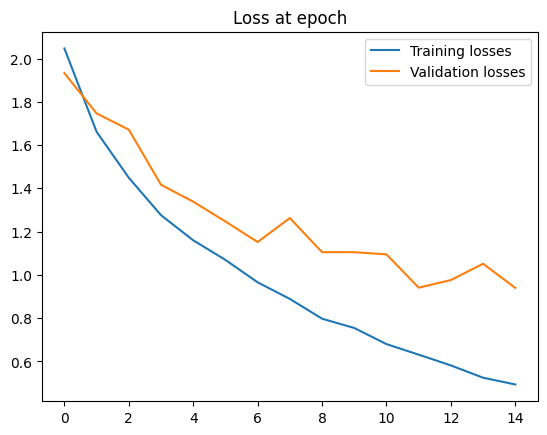

In [ ]:
#train_losses = [tl.item() for tl in train_losses]
#test_losses = [ts.item() for ts in test_losses]
train_losses = [tl.item() if isinstance(tl, torch.Tensor) else tl for tl in train_losses]
test_losses = [ts.cpu().item() if isinstance(ts, torch.Tensor) else ts for ts in test_losses]
plt.plot(train_losses, label = "Training losses")
plt.plot(test_losses, label = 'Validation losses')
plt.title("Loss at epoch")
plt.legend()


In [ ]:
test_losses

[1.9326714953271353,
 1.7463022208795316,
 1.6712594250353372,
 1.416465500869402,
 1.3382786050802324,
 1.2467530853137738,
 1.1517899992262446,
 1.2627453883973563,
 1.1048483821313555,
 1.104860299062438,
 1.0947675061662023,
 0.9408771680986009,
 0.9760064429989675,
 1.0515268325078777,
 0.9395767926442914]

In [ ]:
len(test_dataset)

5236

In [ ]:
tst_corr.item()

3688

In [ ]:
percentage = (tst_corr.item()/len(test_dataset))*100
print(f"Percentage of correct: {percentage:.2f}%")

Percentage of correct: 70.44%


In [ ]:
for i in range(num_classes):
  accuracy_per_class_train = (train_correct_per_class[i]/train_count_per_class[i]) * 100

  print(f"Training accuracy in class {i} = {accuracy_per_class_train:.2f}")

Training accuracy in class 0 = 47.56
Training accuracy in class 1 = 62.82
Training accuracy in class 2 = 72.35
Training accuracy in class 3 = 74.87
Training accuracy in class 4 = 64.34
Training accuracy in class 5 = 67.88
Training accuracy in class 6 = 63.72
Training accuracy in class 7 = 66.17
Training accuracy in class 8 = 71.03
Training accuracy in class 9 = 63.46


In [ ]:
for i in range(num_classes):
  accuracy_per_class_test = (test_correct_per_class[i]/test_count_per_class[i]) * 100
  print(f"Testing accuracy in class {i} = {accuracy_per_class_test:.2f}%")

Testing accuracy in class 0 = 43.76%
Testing accuracy in class 1 = 62.84%
Testing accuracy in class 2 = 68.62%
Testing accuracy in class 3 = 72.55%
Testing accuracy in class 4 = 63.12%
Testing accuracy in class 5 = 60.55%
Testing accuracy in class 6 = 52.72%
Testing accuracy in class 7 = 59.40%
Testing accuracy in class 8 = 59.95%
Testing accuracy in class 9 = 56.84%


In [ ]:
for i in range(15):
  print(f"F1 score in epoch {i} is {f1_score_per_epoch[i]}")

F1 score in epoch 0 is 0.32483207564192634
F1 score in epoch 1 is 0.40711262504733353
F1 score in epoch 2 is 0.44340460010966076
F1 score in epoch 3 is 0.5239050097091899
F1 score in epoch 4 is 0.5554293428981942
F1 score in epoch 5 is 0.5737259261512705
F1 score in epoch 6 is 0.6301525743128504
F1 score in epoch 7 is 0.5915019633642513
F1 score in epoch 8 is 0.6446881561759932
F1 score in epoch 9 is 0.6414929933319183
F1 score in epoch 10 is 0.6623052754256813
F1 score in epoch 11 is 0.7032125125239611
F1 score in epoch 12 is 0.7071137115549448
F1 score in epoch 13 is 0.6824922325360712
F1 score in epoch 14 is 0.7051037765566274


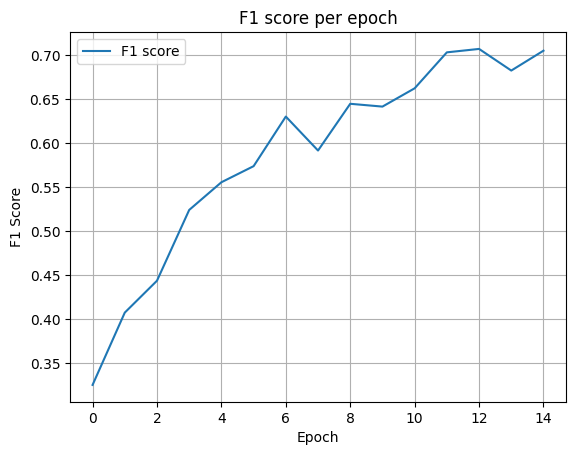

In [ ]:
#train_losses = [tl.item() for tl in train_losses]
#test_losses = [ts.item() for ts in test_losses]

f1_score_graph = [tl.item() if isinstance(tl, torch.Tensor) else tl for tl in f1_score_per_epoch]
plt.plot(f1_score_per_epoch, label = "F1 score")
plt.title("F1 score per epoch")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()


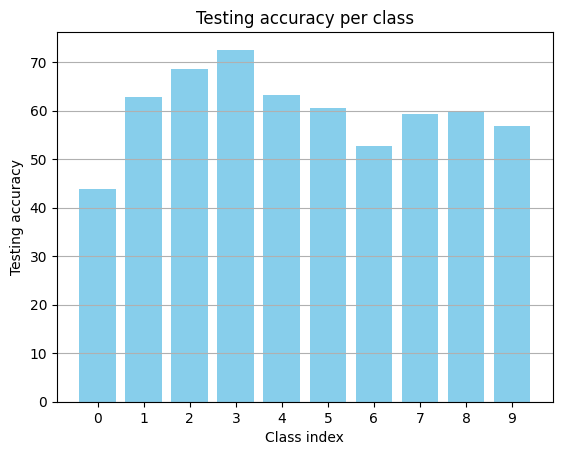

In [ ]:

test_accuracy_per_class = []

for i in range(num_classes):
  test_accuracy_per_class.append((test_correct_per_class[i]/test_count_per_class[i]) * 100)


test_accuracy_graph = [tl.item() if isinstance(tl, torch.Tensor) else tl for tl in test_accuracy_per_class]

plt.bar(range(num_classes), test_accuracy_graph, color='skyblue')
plt.title("Testing accuracy per class")
plt.xlabel("Class index")
plt.ylabel("Testing accuracy")
plt.xticks(range(num_classes))  # show all epoch numbers
plt.grid(axis='y')
plt.show()